In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
FD = pd.read_csv("C:\\Users\\ty\\Downloads\\Kene_projects\\Fraud Detection Project\\Kaggle Fraud Data for Testing\\CSV\\Wrangled\\cleaned_fraud_data.csv")

In [5]:
FD['is_fraud'].value_counts()

is_fraud
0    283253
1       473
Name: count, dtype: int64

In [6]:
# Transactiom Amount Comparison
FD.groupby('is_fraud')['transaction_amount'].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


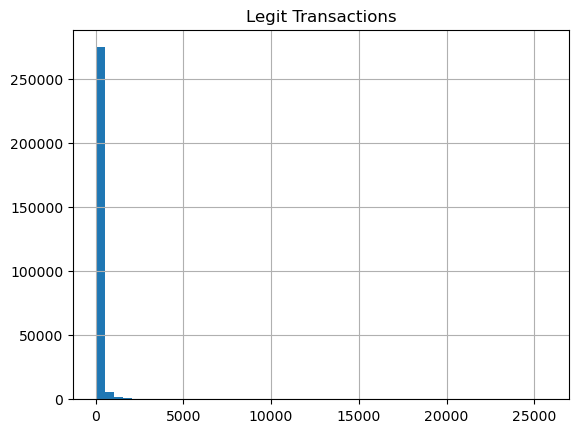

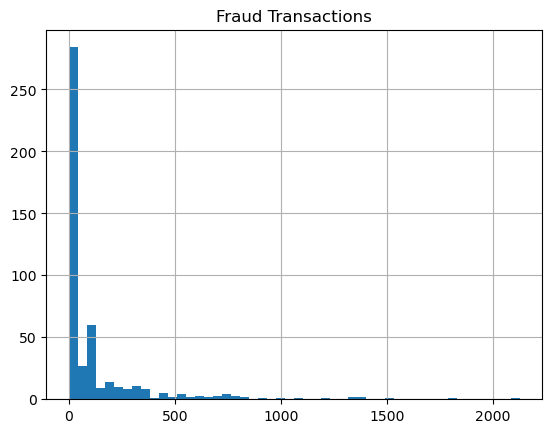

In [7]:
# Chart For Transaction AMount Comparison
FD[FD['is_fraud'] == 0]['transaction_amount'].hist(bins=50)
plt.title("Legit Transactions")
plt.show()

FD[FD['is_fraud'] == 1]['transaction_amount'].hist(bins=50)
plt.title("Fraud Transactions")
plt.show()

In [8]:
# Time Based Patterns
FD['transaction_hour'] = (FD['transaction_time'] // 3600) % 24
FD.groupby('transaction_hour')['is_fraud'].mean()

transaction_hour
0.0     0.000785
1.0     0.002376
2.0     0.014510
3.0     0.004875
4.0     0.010436
5.0     0.003681
6.0     0.002205
7.0     0.003180
8.0     0.000880
9.0     0.001015
10.0    0.000483
11.0    0.003158
12.0    0.001105
13.0    0.001109
14.0    0.001392
15.0    0.001588
16.0    0.001342
17.0    0.001736
18.0    0.001651
19.0    0.001221
20.0    0.001078
21.0    0.000908
22.0    0.000585
23.0    0.001562
Name: is_fraud, dtype: float64

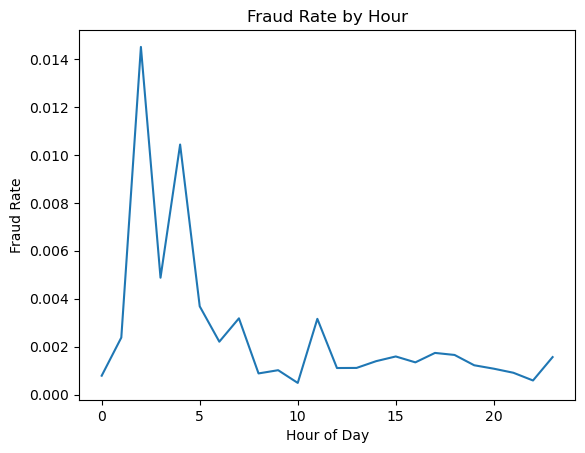

In [9]:
# Time Based Chart
FD.groupby('transaction_hour')['is_fraud'].mean().plot()
plt.title("Fraud Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate")
plt.show()

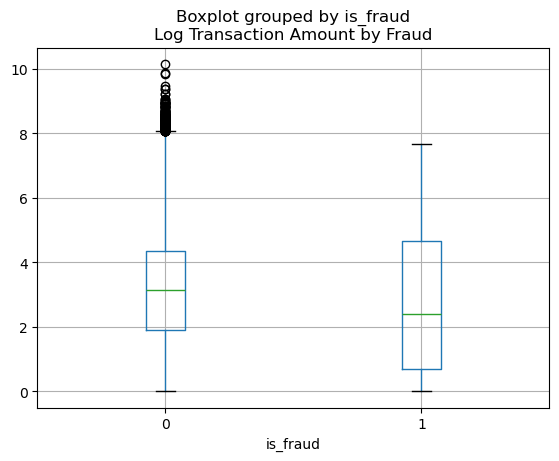

In [10]:
# Transaction Amount vs Fraud
FD['log_amount'] = np.log1p(FD['transaction_amount'])
FD.boxplot(column='log_amount', by='is_fraud')
plt.title("Log Transaction Amount by Fraud")
plt.show()

In [11]:
# Fraud Correlation
FD.corr()['is_fraud'].sort_values(ascending=False)

is_fraud              1.000000
V11                   0.149067
V4                    0.129326
V2                    0.084624
V19                   0.033631
V8                    0.033068
V21                   0.026357
V27                   0.021892
V20                   0.021486
V28                   0.009682
transaction_amount    0.005777
V22                   0.004887
V26                   0.004265
V25                   0.003202
customer_id           0.001044
V15                  -0.003300
V13                  -0.003897
V23                  -0.006333
V24                  -0.007210
log_amount           -0.007798
transaction_id       -0.011911
transaction_time     -0.012359
transaction_hour     -0.016740
V6                   -0.043915
V5                   -0.087812
V9                   -0.094021
V1                   -0.094486
V18                  -0.105340
V7                   -0.172347
V3                   -0.182322
V16                  -0.187186
V10                  -0.206971
V12     

In [12]:
FD

,transaction_id,customer_id,transaction_time,transaction_amount,is_fraud,V1,V2,V3,V4,V5,...,V21,V22,V23,V24,V25,V26,V27,V28,transaction_hour,log_amount
0,1,1924,0.0,149.62,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.0,5.014760
1,2,1762,0.0,2.69,0,1.191857,0.266151,0.166480,0.448154,0.060018,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0.0,1.305626
2,3,1613,1.0,378.66,0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0.0,5.939276
3,4,1614,1.0,123.50,0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.0,4.824306
4,5,1973,2.0,69.99,0,-1.158233,0.877737,1.548718,0.403034,-0.407193,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.0,4.262539
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283721,283722,1994,172786.0,0.77,0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,23.0,0.570980
283722,283723,1045,172787.0,24.79,0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,23.0,3.249987
283723,283724,1589,172788.0,67.88,0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,23.0,4.232366
283724,283725,1722,172788.0,10.00,0,-0.240440,0.530483,0.702510,0.689799,-0.377961,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,23.0,2.397895
